In [2]:
# House Price Prediction using Linear Regression

## 1. Import Libraries
# Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load Dataset

# Load Dataset

train_df = pd.read_csv("../data/train.csv")

# Display first five rows
train_df.head()
## 3. Dataset Overview

## 4. Data Cleaning

## 5. Exploratory Data Analysis (EDA)

## 6. Feature Selection

## 7. Train-Test Split

## 8. Model Training

## 9. Model Evaluation

## 10. Predictions

## 11. Conclusion

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Dataset Shape

print("Rows :", train_df.shape[0])
print("Columns :", train_df.shape[1])

Rows : 1460
Columns : 81


## 3. Dataset Overview


In [5]:
# Dataset Information

train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
# Statistical Summary

train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
# Missing Values

missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [8]:
print("Total Columns :", train_df.shape[1])

print("Columns with Missing Values :", missing_values.count())

Total Columns : 81
Columns with Missing Values : 19


In [10]:
print("Total Columns :", train_df.shape[1])
print("Columns with Missing Values :", missing_values.count())

Total Columns : 81
Columns with Missing Values : 19


### Distribution of House Prices


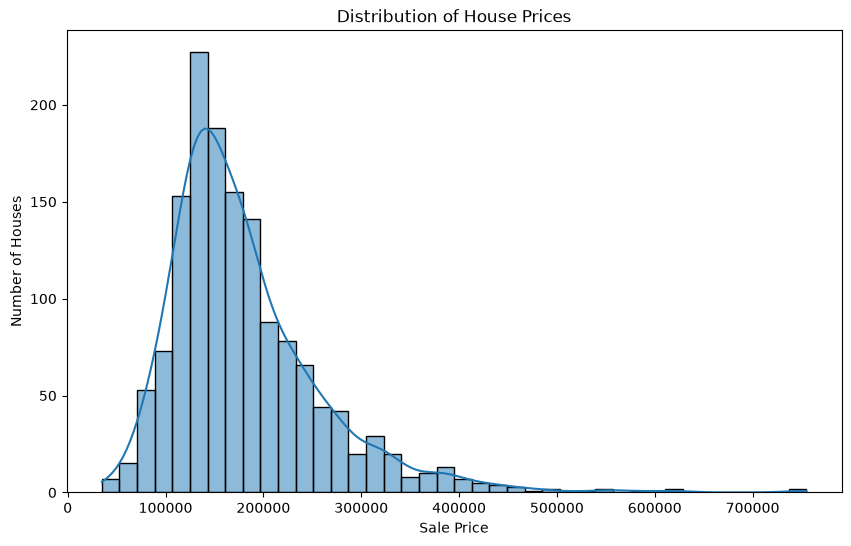

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(train_df["SalePrice"], bins=40, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

**Observation**

- Most houses are concentrated in the lower price range.
- The distribution is positively skewed.
- A few expensive

## Correlation Heatmap

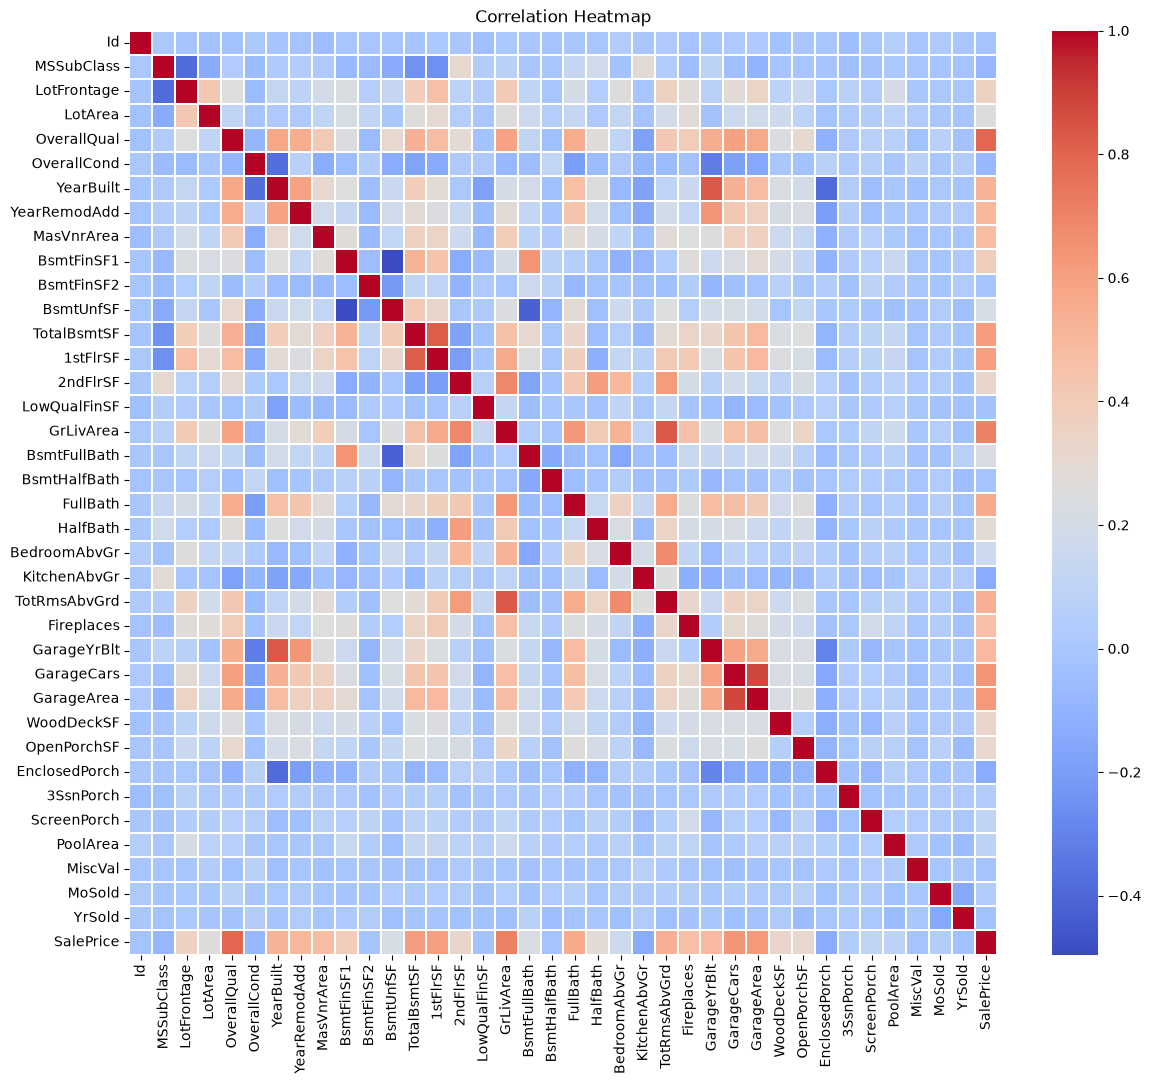

In [12]:
plt.figure(figsize=(14,12))

correlation = train_df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Correlation Heatmap")

plt.show()

In [13]:
correlation = train_df.corr(numeric_only=True)

top_features = correlation["SalePrice"].sort_values(ascending=False)

top_features.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

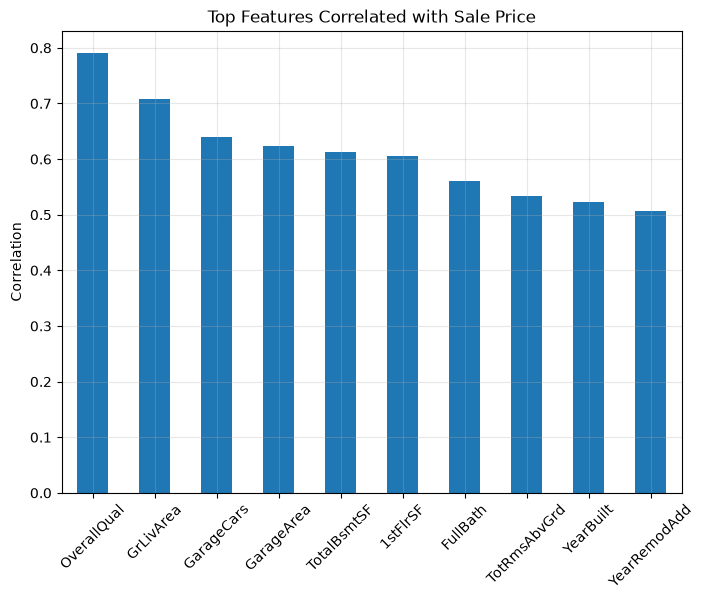

In [14]:
plt.figure(figsize=(8,6))

top_features[1:11].plot(kind="bar")

plt.title("Top Features Correlated with Sale Price")

plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.show()

## Living Area vs Sale Price

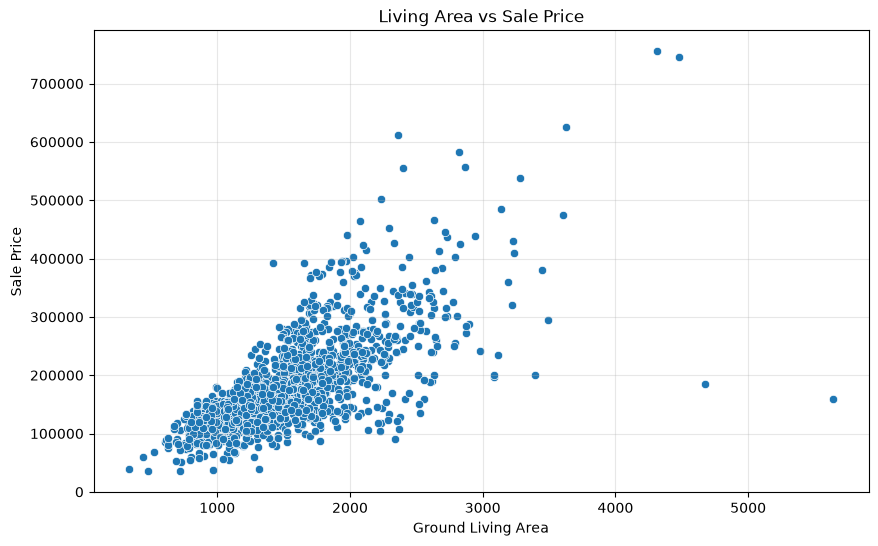

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=train_df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")

plt.xlabel("Ground Living Area")

plt.ylabel("Sale Price")

plt.grid(alpha=0.3)

plt.show()

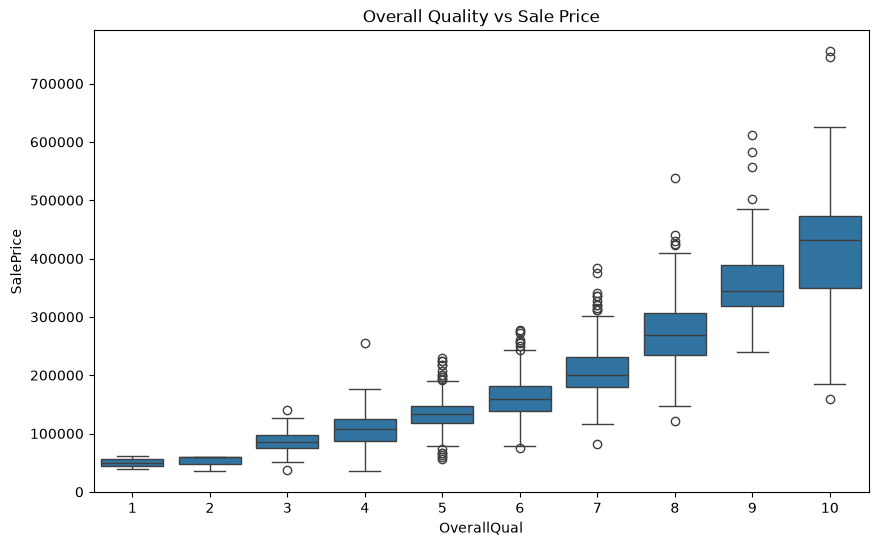

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=train_df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")

plt.show()

# 4. Data Cleaning

In [17]:
# Select required columns

df = train_df[[
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "SalePrice"
]]

df.head()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


In [18]:
# Check missing values

df.isnull().sum()

GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64

In [19]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1460
Columns : 4


In [20]:
# Features

X = df[[
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath"
]]

# Target

y = df["SalePrice"]

print(X.head())
print()
print(y.head())

   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [21]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (1460, 3)
Target Shape : (1460,)


# 5. Train-Test Split

In [22]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (1168, 3)
Testing Features  : (292, 3)
Training Target   : (1168,)
Testing Target    : (292,)


# 6. Model Training

In [24]:
# Create the model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,GrLivArea,104.026307
1,BedroomAbvGr,-26655.165357
2,FullBath,30014.324109


In [26]:
print("Intercept:", model.intercept_)

Intercept: 52261.748626944594


## Model Interpretation

- Positive coefficients indicate that an increase in the feature tends to increase the predicted house price.
- Negative coefficients indicate an inverse relationship.
- The intercept represents the baseline prediction when all feature values are zero.

#  Data Preprocessing

In [27]:
# Separate features and target

X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (1460, 80)
Target Shape   : (1460,)


In [28]:
# Numerical Columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Features :", len(numerical_cols))
print(numerical_cols)

Numerical Features : 37
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='str')


In [29]:
# Categorical Columns

categorical_cols = X.select_dtypes(include=["object"]).columns

print("Categorical Features :", len(categorical_cols))
print(categorical_cols)

Categorical Features : 43
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


In [30]:
# Fill missing numerical values using median

for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())

print("Missing Numerical Values:")
print(X[numerical_cols].isnull().sum().sum())

Missing Numerical Values:
0


In [31]:
# Fill missing categorical values

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing Categorical Values:")
print(X[categorical_cols].isnull().sum().sum())

Missing Categorical Values:
0


In [32]:
# Verify all missing values are handled

print("Total Missing Values :", X.isnull().sum().sum())

Total Missing Values : 0


In [33]:
# One-Hot Encoding

X = pd.get_dummies(X, drop_first=True)

print("New Feature Shape :", X.shape)

New Feature Shape : (1460, 245)


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (1168, 245)
Testing Features  : (292, 245)
Training Target   : (1168,)
Testing Target    : (292,)


In [37]:
print("Missing values in X_train :", X_train.isnull().sum().sum())
print("Missing values in X_test  :", X_test.isnull().sum().sum())

Missing values in X_train : 0
Missing values in X_test  : 0


## Train-Test Split Completed

- Training Data: 80%
- Testing Data: 20%
- Random State: 42
- Ready for Model Training

#  Model Training

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
# Create Linear Regression model

model = LinearRegression()

In [40]:
# Train the model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [41]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.head(20)

,Feature,Coefficient
0,Id,0.150592
1,MSSubClass,-97.910215
2,LotFrontage,-164.351707
3,LotArea,0.637638
4,OverallQual,7277.253760
5,OverallCond,5189.436631
6,YearBuilt,219.941658
7,YearRemodAdd,88.630436
8,MasVnrArea,17.376769
9,BsmtFinSF1,3.569917


In [42]:
print("Intercept :", model.intercept_)

Intercept : 948588.7158626897


In [43]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient
90,Condition2_PosA,100882.827018
117,RoofMatl_WdShngl,91675.267201
184,Heating_Wall,59657.888803
241,SaleCondition_Alloca,56071.028264
229,MiscFeature_Othr,51293.663390
110,RoofStyle_Shed,50355.997765
88,Condition2_Feedr,49804.709450
111,RoofMatl_CompShg,47604.711373
165,BsmtCond_Po,45699.630755
77,Neighborhood_StoneBr,45293.266801


In [53]:
# Save coefficients

coefficients.to_csv(
    "../outputs/results/feature_coefficients.csv",
    index=False
)

print("Feature coefficients saved successfully!")

Feature coefficients saved successfully!


In [54]:
import joblib

In [67]:
import os

print(os.getcwd())

c:\Users\thode\OneDrive\SCT_ML_Task01_HousePrice\notebooks


In [68]:
import os

print(os.path.exists("../models"))

False


In [69]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder created successfully!")

Models folder created successfully!


In [70]:
joblib.dump(model, "../models/linear_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Model Summary

- Algorithm: Linear Regression
- Training Data: 80%
- Testing Data: 20%
- Model trained successfully.
- Model saved for future use.

## Model Evaluation & Predictions

In [71]:
# Predict house prices

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[156441.38852364 339187.42788377  86610.6537886  187116.25956571
 320803.73856029  64107.21804402 254169.9851     145624.71308418
  53010.1106972  155793.97811051]


In [72]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [73]:
# Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 20383.82
MSE  : 1019680445.31
RMSE : 31932.44
R² Score : 0.8671


In [74]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,2.038382e+04
1,MSE,1.019680e+09
2,RMSE,3.193244e+04
3,R2 Score,8.670617e-01


In [75]:
metrics.to_csv(
    "../outputs/results/model_metrics.csv",
    index=False
)

print("Metrics saved successfully!")

Metrics saved successfully!


## Actual vs Predicted House Prices

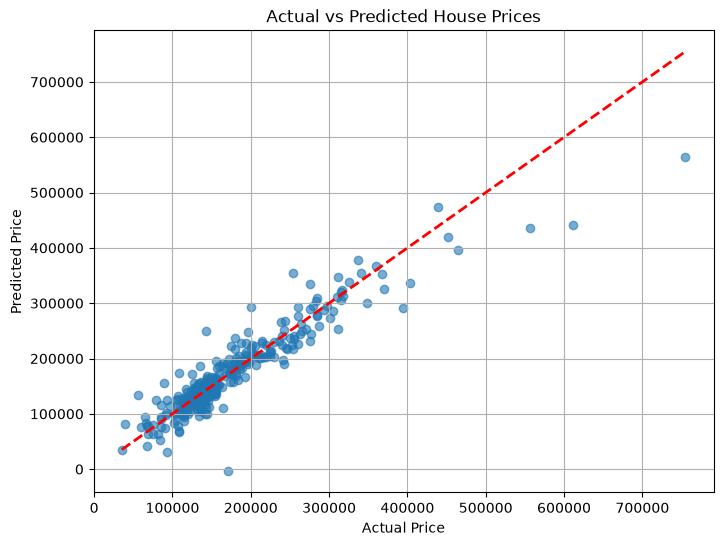

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

## Residual Plot

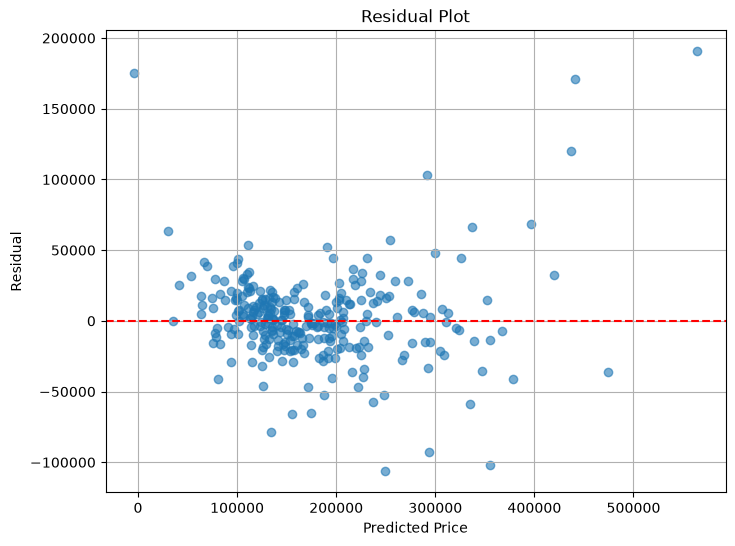

In [78]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

## Error Distribution

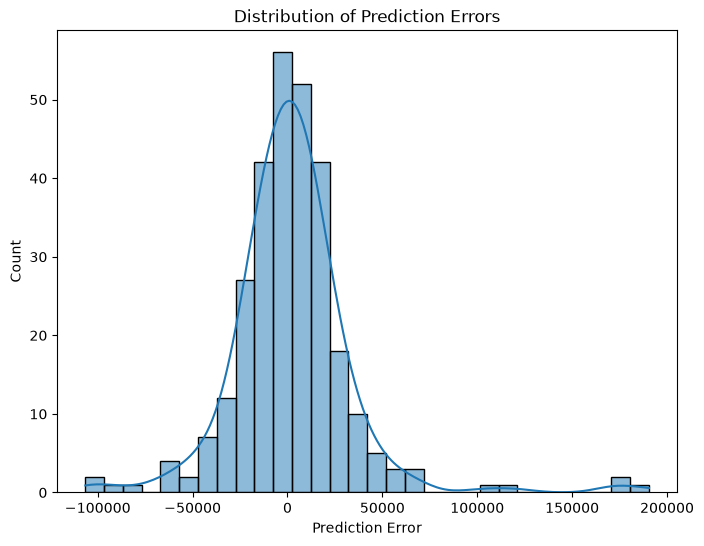

In [79]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Prediction Errors")

plt.xlabel("Prediction Error")

plt.show()

In [80]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(20)

,Actual Price,Predicted Price
0,154500,156441.388524
1,325000,339187.427884
2,115000,86610.653789
3,159000,187116.259566
4,315500,320803.738560
5,75500,64107.218044
6,311500,254169.985100
7,146000,145624.713084
8,84500,53010.110697
9,135500,155793.978111


In [81]:
joblib.dump(
    model,
    "../models/linear_regression_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# 8. Conclusion

- Successfully built a Linear Regression model to predict house prices.
- Performed data preprocessing and feature engineering.
- Evaluated the model using MAE, MSE, RMSE, and R² Score.
- Visualized prediction performance with professional plots.
- Saved the trained model, metrics, and predictions for future use.

# Key Findings

## Dataset
- Total Records: 1460
- Total Features: 81

## Model
- Algorithm: Linear Regression

## Performance
- MAE: (2.038382e+04)
- RMSE: (3.193244e+04)
- R² Score: (8.670617e-01)

## Important Features
- Overall Quality
- Ground Living Area
- Garage Capacity
- Total Basement Area

## Conclusion
The Linear Regression model successfully predicts house prices using housing characteristics. The model demonstrates good predictive performance and can serve as a baseline for more advanced regression models.